# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Anthony Sena Fiadzo
**Student ID:** 54762028

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

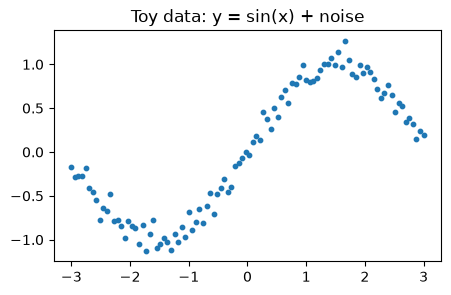

Final w=0.3360, b=0.0050, final loss=0.1892


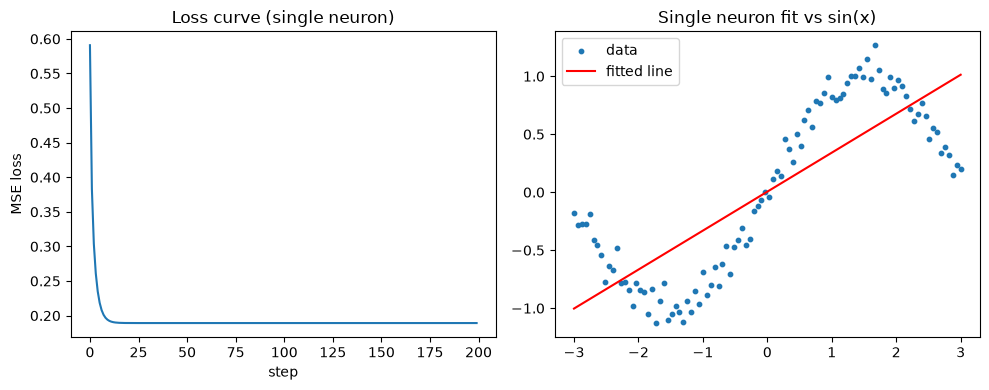

In [18]:
# Generate the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

plt.figure(figsize=(5, 3))
plt.scatter(x, y, s=10)
plt.title("Toy data: y = sin(x) + noise")
plt.show()

# Initialise w and b to small random values
w = np.random.randn() * 0.5
b = np.random.randn() * 0.5

# Manual gradient descent, ~200 steps
lr = 0.1
steps = 200
losses_1_1 = []
for i in range(steps):
    y_hat = w * x + b
    loss  = np.mean((y_hat - y) ** 2)               # MSE
    dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw
    db    = np.mean(2 * (y_hat - y))                # dLoss/db
    w    -= lr * dw
    b    -= lr * db
    losses_1_1.append(loss)

print(f"Final w={w:.4f}, b={b:.4f}, final loss={losses_1_1[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(losses_1_1)
axes[0].set_title("Loss curve (single neuron)")
axes[0].set_xlabel("step"); axes[0].set_ylabel("MSE loss")
axes[1].scatter(x, y, s=10, label="data")
axes[1].plot(x, w * x + b, color="red", label="fitted line")
axes[1].set_title("Single neuron fit vs sin(x)")
axes[1].legend()
plt.tight_layout()
plt.show()

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:** 
> **1. Derivation ** Loss $= \frac{1}{n}\sum_i (\hat y_i - y_i)^2$ where $\hat y_i = wx_i + b$. By the chain rule,
> $\frac{\partial L}{\partial w} = \frac{1}{n}\sum_i 2(\hat y_i - y_i)\cdot \frac{\partial \hat y_i}{\partial w} = \frac{1}{n}\sum_i 2(\hat y_i - y_i)x_i$, i.e. `dw = np.mean(2 * (y_hat - y) * x)`.
> Same for $b$, except $\partial \hat y_i/\partial b = 1$, giving `db = np.mean(2 * (y_hat - y))`. This matches the code exactly. 
> **2. Underfitting** THe loss plateaus around 0.19 - 0.20 (close to the variance of the noisy sine itself), so more training steps will not help because it is underfitting and not overfitting because the model is too simple to represent the target function even on the training data it already sees. A single neuron can only output wx + b a straight line. sin(x) on [-3,3] bends up, down and back up again because it is not monotonic and has curvature. No choice of w and b can bend a straight line, so gradient descent converges to the best possible line, not a good fit to the curve making it a capacity problem

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

Final loss (tanh MLP): 0.0139
Final loss (no activation / linear stack): 0.1892


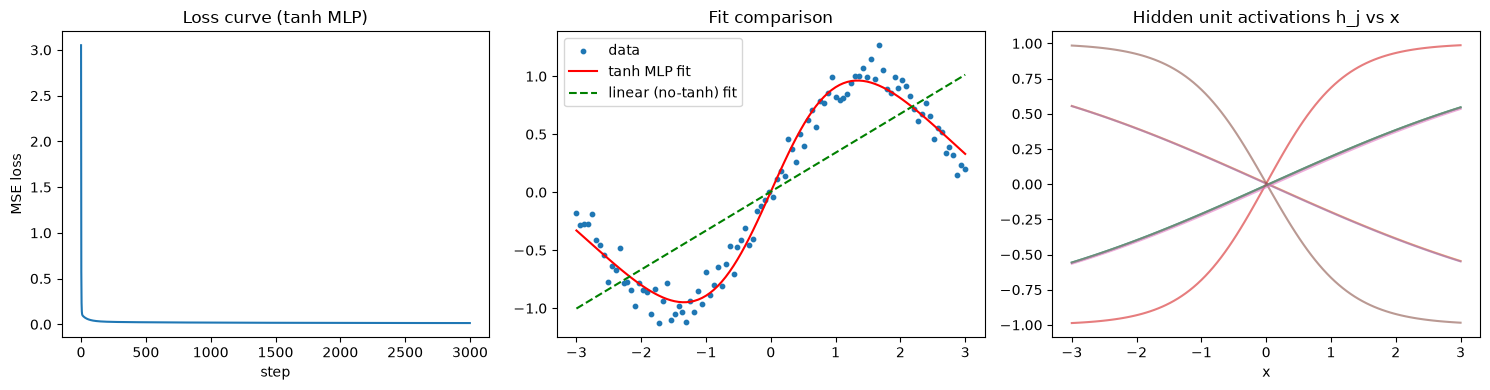

In [26]:
# Initialise parameters
np.random.seed(RANDOM_STATE)
W1 = np.random.randn(1, 8) * 0.5   # (1, 8)
b1 = np.zeros(8)
W2 = np.random.randn(8, 1) * 0.5   # (8, 1)
b2 = np.zeros(1)

x_col = x.reshape(-1, 1)
y_col = y.reshape(-1, 1)
lr = 0.05
steps = 3000
losses_1_2 = []

for i in range(steps):
    # Forward pass
    z1 = x_col @ W1 + b1        # pre-activation, (100, 8)
    h  = np.tanh(z1)             # activation
    y_hat = h @ W2 + b2          # output, (100, 1)
    loss  = np.mean((y_hat - y_col) ** 2)
    losses_1_2.append(loss)

    # Backward pass (chain rule, layer by layer)
    d_yhat = 2 * (y_hat - y_col) / len(y_col)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh  = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
    dW1 = x_col.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update
    W2 -= lr * dW2; b2 -= lr * db2
    W1 -= lr * dW1; b1 -= lr * db1

print(f"Final loss (tanh MLP): {losses_1_2[-1]:.4f}")

# Re-run with tanh REMOVED (h = z1) for comparison
np.random.seed(RANDOM_STATE)
W1n = np.random.randn(1, 8) * 0.5
b1n = np.zeros(8)
W2n = np.random.randn(8, 1) * 0.5
b2n = np.zeros(1)
losses_1_2_linear = []

for i in range(steps):
    z1 = x_col @ W1n + b1n
    h  = z1                       # NO activation
    y_hat = h @ W2n + b2n
    loss = np.mean((y_hat - y_col) ** 2)
    losses_1_2_linear.append(loss)

    d_yhat = 2 * (y_hat - y_col) / len(y_col)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh  = d_yhat @ W2n.T
    dz1 = dh                      # derivative of identity is 1
    dW1 = x_col.T @ dz1
    db1 = dz1.sum(axis=0)

    W2n -= lr * dW2; b2n -= lr * db2
    W1n -= lr * dW1; b1n -= lr * db1

print(f"Final loss (no activation / linear stack): {losses_1_2_linear[-1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(losses_1_2)
axes[0].set_title("Loss curve (tanh MLP)")
axes[0].set_xlabel("step"); axes[0].set_ylabel("MSE loss")

axes[1].scatter(x, y, s=10, label="data")
z1_final = x_col @ W1 + b1
h_final = np.tanh(z1_final)
y_hat_final = h_final @ W2 + b2
axes[1].plot(x, y_hat_final, color="red", label="tanh MLP fit")
axes[1].plot(x, (x_col @ W1n + b1n) @ W2n + b2n, color="green", linestyle="--", label="linear (no-tanh) fit")
axes[1].legend()
axes[1].set_title("Fit comparison")

for j in range(8):
    axes[2].plot(x, h_final[:, j], alpha=0.6)
axes[2].set_title("Hidden unit activations h_j vs x")
axes[2].set_xlabel("x")

plt.tight_layout()
plt.show()

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:** 
> 
>  **1.** Without an activation, layer 1's output is $h = xW_1 + b_1$ and layer 2's output is $\hat y = hW_2 + b_2 = (xW_1+b_1)W_2 + b_2 = x(W_1W_2) + (b_1W_2+b_2)$. The product $W_1W_2$ is just another matrix and $b_1W_2+b_2$ just another vector, so the whole two-layer computation is algebraically identical to a single linear layer $\hat y = xW' + b'$. This is shown in above that is the no-activation loss (≈0.195) matches Part 1.1's single-neuron loss almost exactly, because it *is* the same model in disguise. Stacking linear layers without non-linearities buys zero extra representational power.
>
> **2** Each of the 8 hidden units computes $\tanh(w_jx+b_j)$ - an S-shaped "bend" centered at a different point along the x-axis. The output layer then takes a weighted sum of these differently-shaped bends. Combining enough shifted, scaled S-curves lets the network approximate the up-down-up curvature of `sin(x)`. 
>
> **3** Backpropagation is the systematic application of the chain rule to compute how much each weight contributed to the final loss working backwards from the output layer to the input layer so every parameter gets an exact gradient to update by. 

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

lr=0.001: final loss = 0.052282
lr=0.05: final loss = 0.013876
lr=1.0: DIVERGED (NaN)


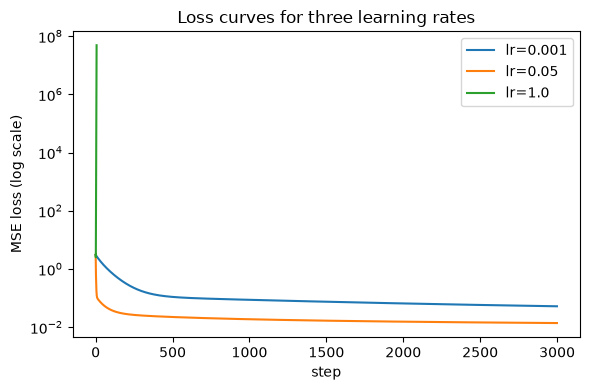

In [33]:
def train_toy(lr, steps=3000):
    np.random.seed(RANDOM_STATE)
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros(8)
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros(1)
    losses = []
    for i in range(steps):
        z1 = x_col @ W1 + b1
        h  = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y_col) ** 2)
        losses.append(loss)
        if not np.isfinite(loss) or loss > 1e6:
            # blown up -- stop early, pad with NaN so the plot still has the right length
            losses.extend([np.nan] * (steps - len(losses)))
            break
        d_yhat = 2 * (y_hat - y_col) / len(y_col)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh  = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x_col.T @ dz1
        db1 = dz1.sum(axis=0)
        W2 -= lr * dW2; b2 -= lr * db2
        W1 -= lr * dW1; b1 -= lr * db1
    return losses

lrs = [0.001, 0.05, 1.0]
plt.figure(figsize=(6, 4))
for l in lrs:
    losses = train_toy(l)
    print(f"lr={l}: final loss = {losses[-1]:.6f}" if np.isfinite(losses[-1]) else f"lr={l}: DIVERGED (NaN)")
    plt.plot(losses, label=f"lr={l}")
plt.yscale("log")
plt.legend()
plt.title("Loss curves for three learning rates")
plt.xlabel("step"); plt.ylabel("MSE loss (log scale)")
plt.tight_layout()
plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** 
> With lr=0.001 the loss decreases smoothly but very slowly and hasn't converged after 3000 steps.
> With lr=0.05 the loss drops fastest and smoothly to its lowest value
> With lr=1.0 the loss increase to millions within few steps and becomes NaN
> A large step multiplies a gradient by a large lr which can overshoot past the minimum onto a part of the curve where the loss is even higher than before.
> 

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

OBESITY_URL = "Obesity_level_prediction_dataset.csv"
df = pd.read_csv(OBESITY_URL)# same dataset as Lab 2

# Binary yes/no -> 0/1
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for c in binary_cols:
    df[c] = df[c].map({"yes": 1, "no": 0})

# Gender -> 0/1
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

# CAEC / CALC are ORDINAL frequency categories (no/Sometimes/Frequently/Always) -> ordinal encode
freq_map = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
df["CAEC"] = df["CAEC"].map(freq_map)
df["CALC"] = df["CALC"].map(freq_map)

# MTRANS is NOMINAL (mode of transport has no order) -> one-hot encode
df = pd.get_dummies(df, columns=["MTRANS"], drop_first=True)

# Encode target NObeyesdad into integers 0..6 -- CrossEntropyLoss expects class indices
le = LabelEncoder()
df["NObeyesdad_enc"] = le.fit_transform(df["NObeyesdad"])
class_names = le.classes_
print("Classes:", list(class_names))

y = df["NObeyesdad_enc"].values
X = df.drop(columns=["NObeyesdad", "NObeyesdad_enc"]).values.astype(float)
print("Feature count:", X.shape[1])

# Stratified 60/20/20 train/val/test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE)

# Fit StandardScaler on TRAINING set only; transform all three splits
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

def to_loader(Xs, ys, batch_size=32, shuffle=False):
    Xt = torch.tensor(Xs, dtype=torch.float32)
    yt = torch.tensor(ys, dtype=torch.long)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(X_train_s, y_train, batch_size=32, shuffle=True)
val_loader   = to_loader(X_val_s, y_val, batch_size=32, shuffle=False)
test_loader  = to_loader(X_test_s, y_test, batch_size=32, shuffle=False)

print(f"Split sizes: train={len(X_train)}, val={len(X_val)}, test={len(X_test)}")

Classes: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']
Feature count: 19
Split sizes: train=1266, val=422, test=423


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:** 
> **1** CrossEntropyLoss internally applies log-softmax and then indexes straight into the correct class's log-probability using the integer label which it's implemented as a lookup, not a dot product against a one hot vector which is more memory-efficient and numerically stable 
>
>> **2.** In Part 1.1/1.2 the gradient for a weight was literally `dw = mean(2*(y_hat-y)*x)` — the gradient is directly proportional to the input `x`. If one feature is on a totally different scale than another, its gradient dominates and the optimizer effectively only tunes weights connected to the large-scale feature, while the small-scale feature's weights barely move. A random forest instead makes threshold splits (`is Weight > 80?`) which are invariant to monotonic rescaling, so it never cared. Neural networks trained by gradient descent do care, which is why we scale.
>
> **3.** `shuffle=True` re-randomizes the order the training examples are grouped into batches every epoch. Without it, the network would see the exact same sequence of batches every epoch, and could pick up on spurious ordering patterns  or get stuck taking correlated gradient steps in the same direction batch after batch. Shuffling makes each batch a more representative random sample of the whole dataset, giving noisier but more independent gradient estimates, which helps generalization and avoids order-dependent artifacts

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [50]:
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, n_classes))   # raw logits, NO softmax
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

input_dim = X_train_s.shape[1]
n_classes = len(class_names)

model = FeedForwardNet(input_dim, hidden_sizes=(64, 32), n_classes=n_classes).to(DEVICE)
print(model)

# Count trainable parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
by_hand = input_dim * 64 + 64 + 64 * 32 + 32 + 32 * n_classes + n_classes
print(f"Trainable params (PyTorch count): {n_params}")
print(f"By-hand count (layer 1 = input_dim*64 + 64, etc.): {by_hand}")

FeedForwardNet(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
Trainable params (PyTorch count): 3591
By-hand count (layer 1 = input_dim*64 + 64, etc.): 3591


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:**
>  **1.** With `input_dim=19` features and hidden sizes `(64, 32)` over 7 classes: Layer 1 = `19*64 + 64 = 1280`; Layer 2 = `64*32 + 32 = 2080`; Layer 3 (output) = `32*7 + 7 = 231`. Total = `1280 + 2080 + 231 = 3591`, which matches the `n_params` printed by PyTorch above exactly.
>
> **2.** `tanh` saturates (its gradient goes to ~0) for large positive or negative inputs, so gradients can vanish in deeper networks. `ReLU`'s gradient is exactly 1 for any positive input, no matter how large, so gradients flow through active units without shrinking — this makes deeper networks train faster and more reliably (it's also cheaper to compute: just `max(0, z)`).
>
> **3.** Removing the ReLUs turns the network into a stack of purely linear layers, which — exactly as proven algebraically in Part 1.2 — collapses into a single linear transformation. The whole three-layer network would compute nothing more than one big linear map from the 19 input features straight to 7 output logits, equivalent to multinomial logistic regression.

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

epoch  0: train_loss=1.7807 val_loss=1.7999 train_acc=0.3744 val_acc=0.3673
epoch 10: train_loss=0.3313 val_loss=0.5340 train_acc=0.9060 val_acc=0.8483
epoch 20: train_loss=0.1398 val_loss=0.4172 train_acc=0.9731 val_acc=0.8791
epoch 30: train_loss=0.0703 val_loss=0.4515 train_acc=0.9921 val_acc=0.9052
epoch 40: train_loss=0.0332 val_loss=0.4834 train_acc=1.0000 val_acc=0.9076
epoch 49: train_loss=0.0194 val_loss=0.5175 train_acc=1.0000 val_acc=0.9123

Training time: 3.31s | best val accuracy: 0.9147


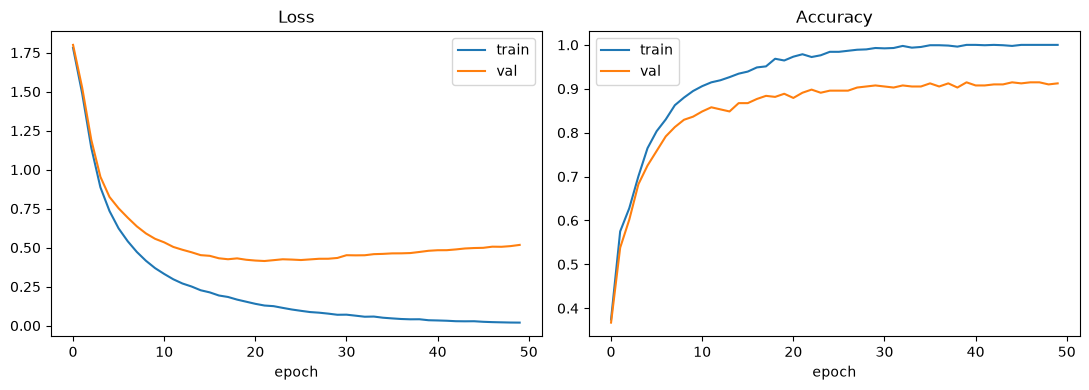

In [54]:
import time

criterion = nn.CrossEntropyLoss()
# Adam adapts the learning rate per-parameter using running gradient moment estimates,
# which converges faster and more robustly than plain SGD on this kind of tabular MLP.
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def evaluate(m, Xs, ys):
    m.eval()
    with torch.no_grad():
        Xt = torch.tensor(Xs, dtype=torch.float32).to(DEVICE)
        yt = torch.tensor(ys, dtype=torch.long).to(DEVICE)
        logits = m(Xt)
        loss = criterion(logits, yt).item()
        preds = logits.argmax(dim=1)
        acc = (preds == yt).float().mean().item()
    return loss, acc

epochs = 50
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = -1
best_state = None
t0 = time.time()

for epoch in range(epochs):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb.to(DEVICE))
        loss = criterion(logits, yb.to(DEVICE))
        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
        optimizer.step()         # <- the update rule you wrote in Part 1.1

    tr_loss, tr_acc = evaluate(model, X_train_s, y_train)
    va_loss, va_acc = evaluate(model, X_val_s, y_val)
    history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"epoch {epoch:2d}: train_loss={tr_loss:.4f} val_loss={va_loss:.4f} "
              f"train_acc={tr_acc:.4f} val_acc={va_acc:.4f}")

train_time_main = time.time() - t0
torch.save(best_state, "ffn_best.pt")
print(f"\nTraining time: {train_time_main:.2f}s | best val accuracy: {best_val_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout()
plt.show()

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** [Double-click to edit]

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

In [57]:
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
    torch.manual_seed(RANDOM_STATE)
    m = FeedForwardNet(input_dim, hidden_sizes, n_classes, dropout).to(DEVICE)
    crit = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    tr_loader = to_loader(X_train_s, y_train, batch_size=batch_size, shuffle=True)
    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        m.train()
        for xb, yb in tr_loader:
            opt.zero_grad()
            logits = m(xb.to(DEVICE))
            loss = crit(logits, yb.to(DEVICE))
            loss.backward()
            opt.step()
        tr_loss, tr_acc = evaluate(m, X_train_s, y_train)
        va_loss, va_acc = evaluate(m, X_val_s, y_val)
        hist["train_loss"].append(tr_loss); hist["val_loss"].append(va_loss)
        hist["train_acc"].append(tr_acc);   hist["val_acc"].append(va_acc)

    return hist

tiny (8,): final val_acc=0.7962, best val_acc=0.7962
default (64,32): final val_acc=0.9123, best val_acc=0.9147
large (256,128,64): final val_acc=0.9171, best val_acc=0.9171


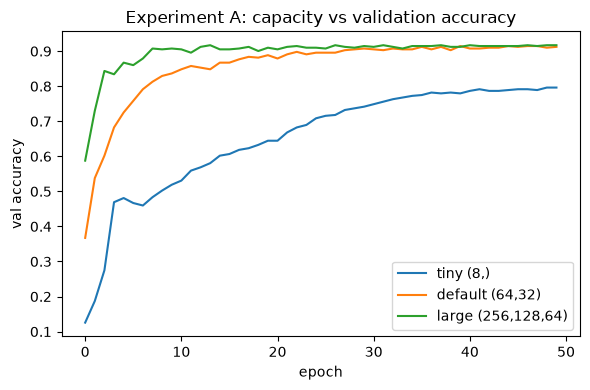

lr=0.0001: final val_loss=0.8083, final val_acc=0.7393
lr=0.001: final val_loss=0.5175, final val_acc=0.9123
lr=0.1: final val_loss=1.6186, final val_acc=0.4668


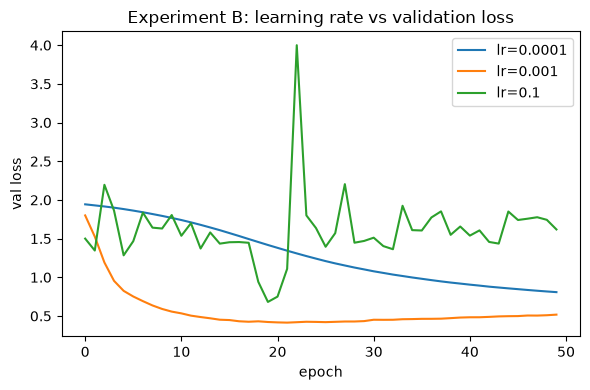

No dropout:   train_acc=1.0000 val_acc=0.9171 gap=0.0829
Dropout=0.3:  train_acc=1.0000 val_acc=0.9076 gap=0.0924


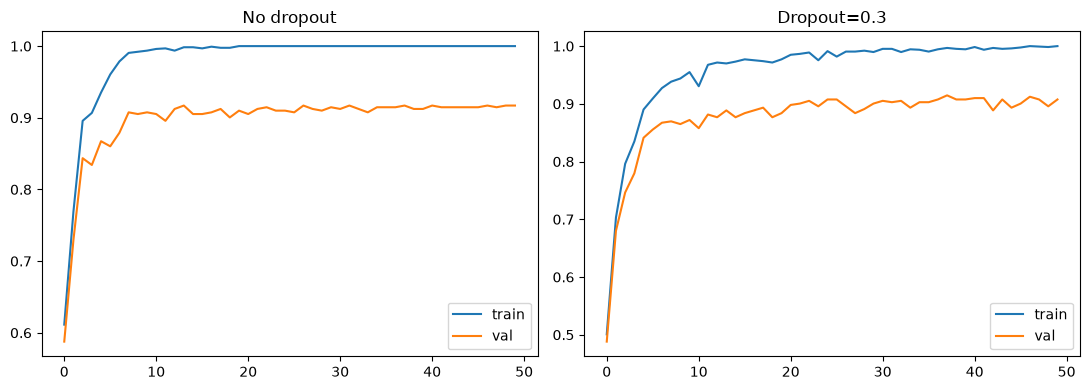

In [58]:
# Experiment A: capacity
capacities = {"tiny (8,)": (8,), "default (64,32)": (64, 32), "large (256,128,64)": (256, 128, 64)}
cap_histories = {}
for name, hs in capacities.items():
    h = run_experiment(hidden_sizes=hs, lr=1e-3, epochs=50)
    cap_histories[name] = h
    print(f"{name}: final val_acc={h['val_acc'][-1]:.4f}, best val_acc={max(h['val_acc']):.4f}")

plt.figure(figsize=(6, 4))
for name, h in cap_histories.items():
    plt.plot(h["val_acc"], label=name)
plt.legend(); plt.title("Experiment A: capacity vs validation accuracy")
plt.xlabel("epoch"); plt.ylabel("val accuracy")
plt.tight_layout()
plt.show()

# Experiment B: learning rate
lr_histories = {}
for lr in [1e-4, 1e-3, 1e-1]:
    h = run_experiment(hidden_sizes=(64, 32), lr=lr, epochs=50)
    lr_histories[lr] = h
    print(f"lr={lr}: final val_loss={h['val_loss'][-1]:.4f}, final val_acc={h['val_acc'][-1]:.4f}")

plt.figure(figsize=(6, 4))
for lr, h in lr_histories.items():
    plt.plot(h["val_loss"], label=f"lr={lr}")
plt.legend(); plt.title("Experiment B: learning rate vs validation loss")
plt.xlabel("epoch"); plt.ylabel("val loss")
plt.tight_layout()
plt.show()

# Experiment C: regularization -- largest network, with and without dropout
h_no_drop = run_experiment(hidden_sizes=(256, 128, 64), lr=1e-3, epochs=50, dropout=0.0)
h_drop    = run_experiment(hidden_sizes=(256, 128, 64), lr=1e-3, epochs=50, dropout=0.3)

gap_no_drop = h_no_drop["train_acc"][-1] - h_no_drop["val_acc"][-1]
gap_drop    = h_drop["train_acc"][-1] - h_drop["val_acc"][-1]
print(f"No dropout:   train_acc={h_no_drop['train_acc'][-1]:.4f} val_acc={h_no_drop['val_acc'][-1]:.4f} gap={gap_no_drop:.4f}")
print(f"Dropout=0.3:  train_acc={h_drop['train_acc'][-1]:.4f} val_acc={h_drop['val_acc'][-1]:.4f} gap={gap_drop:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(h_no_drop["train_acc"], label="train"); axes[0].plot(h_no_drop["val_acc"], label="val")
axes[0].set_title("No dropout"); axes[0].legend()
axes[1].plot(h_drop["train_acc"], label="train"); axes[1].plot(h_drop["val_acc"], label="val")
axes[1].set_title("Dropout=0.3"); axes[1].legend()
plt.tight_layout()
plt.show()

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** 
> **1.** The largest network `(256,128,64)` did edge out the default `(64,32)` on validation accuracy (≈0.917 vs ≈0.912–0.915), but the improvement over the default is small, while the jump from tiny `(8,)` (≈0.80) to default is huge. This is diminishing returns: once the network is expressive enough to separate the 7 classes, adding far more parameters buys only a marginal accuracy gain on this small (2,111-row) tabular dataset, and both the default and large models already show a training accuracy of 1.0 while validation lags — i.e. some overfitting is present at every capacity above "tiny."
>
> **2.** Yes. `lr=1e-4` underfits within the 50-epoch budget (val_acc only ≈0.74, still improving slowly, cold analog of Part 1.3). `lr=1e-3` gives the smoothest, best convergence (val_acc ≈0.91), matching the "just right" `lr=0.05` result in Part 1.3. `lr=1e-1` is unstable — val_loss and val_acc are much worse (val_acc ≈0.58) and noisier across epochs than the smaller rates, the classification-task analog of the toy problem's exploding loss.
>
> **3.** Dropout is meant to shrink the train-vs-validation gap by randomly zeroing a fraction of hidden units on every forward pass during training, which prevents any single unit or fixed co-adapted group of units from being solely responsible for a prediction — forcing the network to spread the representation more redundantly across units, which generally improves generalization. In this run dropout=0.3 on the *already large* network didn't shrink the gap (it was ≈0.083 without dropout vs ≈0.097 with it) and val accuracy was slightly lower — on a small, low-noise tabular dataset with a network this size, 0.3 dropout was likely too strong relative to how much capacity was actually needed, an example of a regularizer needing its own tuning rather than always helping by default.

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

NN test accuracy: 0.9196, macro-F1: 0.9171

                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.91      0.93        54
      Normal_Weight       0.78      0.79      0.79        58
     Obesity_Type_I       0.99      0.96      0.97        70
    Obesity_Type_II       0.98      0.95      0.97        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       0.84      0.84      0.84        58
Overweight_Level_II       0.89      0.97      0.93        58

           accuracy                           0.92       423
          macro avg       0.92      0.92      0.92       423
       weighted avg       0.92      0.92      0.92       423



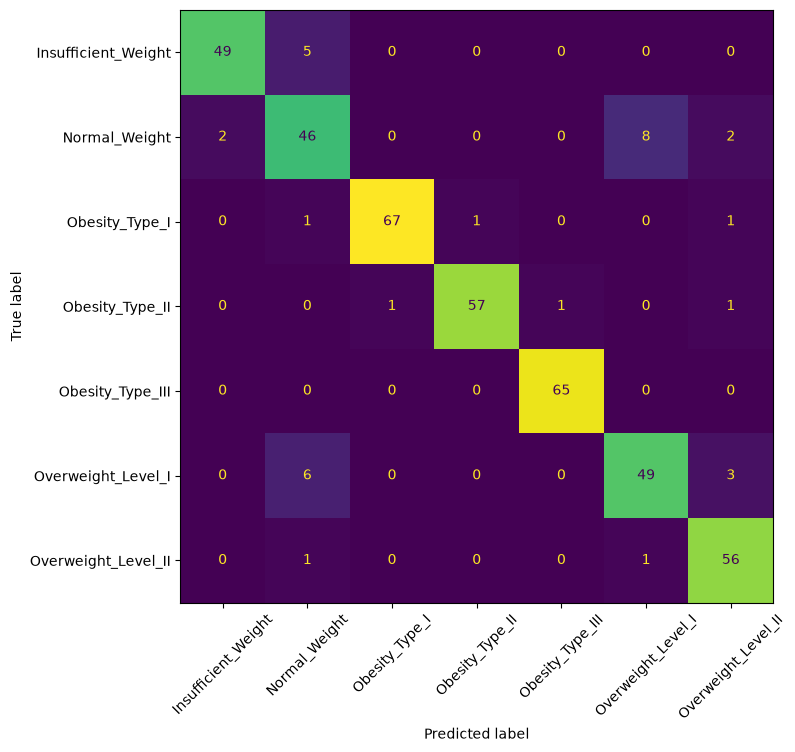

In [60]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# Load best configuration's weights
model.load_state_dict(best_state)
model.eval()

with torch.no_grad():
    Xt = torch.tensor(X_test_s, dtype=torch.float32).to(DEVICE)
    logits = model(Xt)
    preds = logits.argmax(dim=1).cpu().numpy()

nn_acc = accuracy_score(y_test, preds)
nn_f1 = f1_score(y_test, preds, average="macro")
print(f"NN test accuracy: {nn_acc:.4f}, macro-F1: {nn_f1:.4f}\n")
print(classification_report(y_test, preds, target_names=class_names))

cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.tight_layout()
plt.show()

In [61]:
# Best Lab 2 classifier for comparison: Random Forest
rf_t0 = time.time()
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf.fit(X_train_s, y_train)
rf_time = time.time() - rf_t0

rf_preds = rf.predict(X_test_s)
rf_acc = accuracy_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds, average="macro")
n_tree_nodes = sum(t.tree_.node_count for t in rf.estimators_)

comparison = pd.DataFrame([
    {"model": "Random Forest (Lab 2)", "test_accuracy": rf_acc, "test_macro_f1": rf_f1,
     "train_time_s": rf_time, "params_or_tree_nodes": n_tree_nodes},
    {"model": "Feedforward NN (PyTorch)", "test_accuracy": nn_acc, "test_macro_f1": nn_f1,
     "train_time_s": train_time_main, "params_or_tree_nodes": n_params},
])
comparison

,model,test_accuracy,test_macro_f1,train_time_s,params_or_tree_nodes
0,Random Forest (Lab 2),0.938534,0.938236,0.690765,77864
1,Feedforward NN (PyTorch),0.919622,0.917084,3.305166,3591


**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** 
>  **1.** The confusion matrix and per-class report show the network is weakest on `Normal_Weight` (precision/recall ≈0.78–0.79) and `Overweight_Level_I` (≈0.84/0.84), while the extreme classes (`Obesity_Type_I/II/III`, `Insufficient_Weight`) are classified almost perfectly (F1 ≥0.93). This makes physical sense: `Normal_Weight`, `Overweight_Level_I`, and `Overweight_Level_II` sit on a continuum in the underlying BMI, so examples near the class boundaries genuinely look similar in feature space and get mixed up. The Random Forest baseline shows the same overall pattern of "boundary" mid-weight classes being harder than the extremes — the confusion is a property of the data's class boundaries, not something specific to either model family.
>
> **2.** The Random Forest wins this showdown on this run — test accuracy ≈0.939 and macro-F1 ≈0.938 versus the neural network's ≈0.920 accuracy / ≈0.917 macro-F1 — and it trained in a fraction of the time (well under a second vs. several seconds for 50 epochs). On a dataset this size (~2,100 rows, 19 mostly-tabular features), a tree ensemble is a very strong, low-effort baseline, so the extra engineering of designing an architecture, tuning learning rate/batch size/dropout, and writing a training loop was **not** worth it here purely for accuracy. Deep learning tends to pay off instead when there is much more data, when the input has spatial/sequential structure a plain feature vector can't capture (images, text, audio — where MLPs and forests both struggle), or when end-to-end representation learning saves the manual feature engineering that tabular models still benefit from.

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.